# Medical Insurance Cost Prediction
**Project type:** End-to-End Machine Learning Regression
**Model:** Linear Regression
**Goal:** Predict medical insurance `charges` from demographic and lifestyle features, then deploy via Streamlit.

This notebook follows the full workflow: dataset understanding → cleaning → EDA → preprocessing → modeling → evaluation → residual analysis → improvement experiment → saving the final pipeline.

## Phase 1 — Dataset Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

sns.set_style("whitegrid")

df = pd.read_csv("../data/medical-charges.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Observations:**
- The dataset has 1338 rows and 7 columns.
- Numerical columns: `age`, `bmi`, `children`, and the target `charges`.
- Categorical columns: `sex`, `smoker`, `region`.
- `charges` is the target variable — it is a continuous numeric value we want to predict, which is why this is a **regression** problem (not classification). Features (X) are the remaining 6 columns; the target (y) is `charges`.

## Phase 2 — Data Cleaning

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 1
Shape after removing duplicates: (1337, 7)


In [8]:
for col in ["sex", "smoker", "region"]:
    print(f"{col}: {df[col].unique()}")

sex: <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
smoker: <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
region: <ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [9]:
print(df[["age", "bmi", "children", "charges"]].agg(["min", "max"]))

     age    bmi  children      charges
min   18  15.96         0   1121.87390
max   64  53.13         5  63770.42801


**Cleaning decisions:**
- No missing values were found in any column — no imputation needed.
- 1 duplicate row was found and removed (1338 → 1337 rows). This is a real duplicate observation, not information, so it's safe to drop.
- Categorical values (`sex`, `smoker`, `region`) all have clean, expected categories with no misspellings or stray values.
- Numeric ranges (age 18–64, bmi ~16–53, children 0–5) all look medically plausible — no impossible values like negative age or negative charges were found, so no rows were removed on that basis.

## Phase 3 — Exploratory Data Analysis
Each plot below is saved as a PNG in `notebooks/plots/` and displayed inline with a written observation, as required.

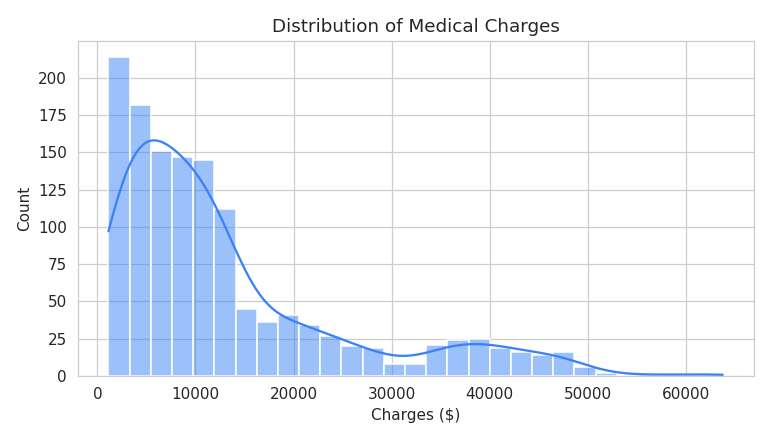

In [10]:
from IPython.display import Image, display
display(Image("plots/01_charges_distribution.png"))

**Observation:** The `charges` distribution is **right-skewed**, not normal — most customers have charges under $15,000, but a long tail extends to over $60,000 (largely driven by smokers, as later plots show).

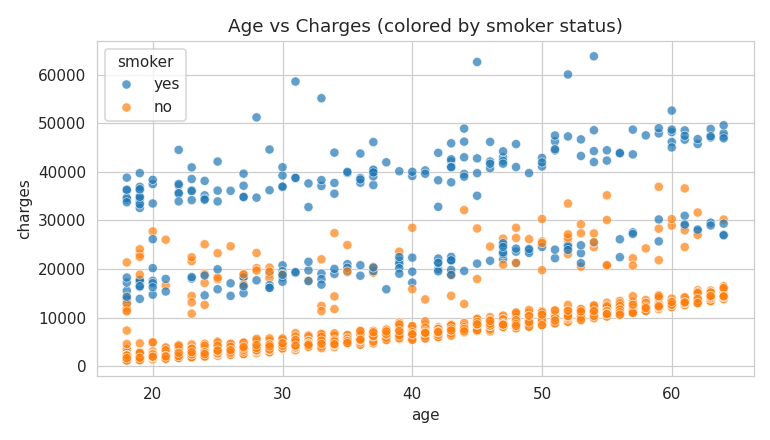

In [11]:
display(Image("plots/02_age_vs_charges.png"))

**Observation:** Charges generally rise with age, visible as three roughly parallel upward bands. Smokers (orange) sit on a much higher band than non-smokers at every age — age matters, but smoking status matters more.

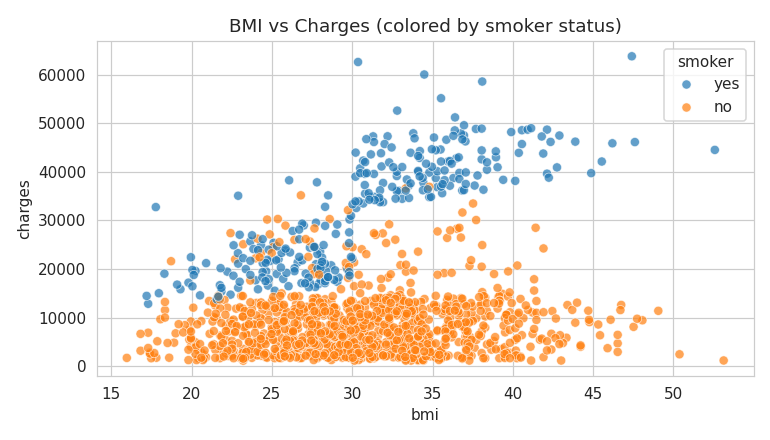

In [12]:
display(Image("plots/03_bmi_vs_charges.png"))

**Observation:** For non-smokers, BMI has only a weak relationship with charges. For smokers, charges rise sharply with BMI — high-BMI smokers are the most expensive group by far. This hints at a real **interaction** between BMI and smoking.

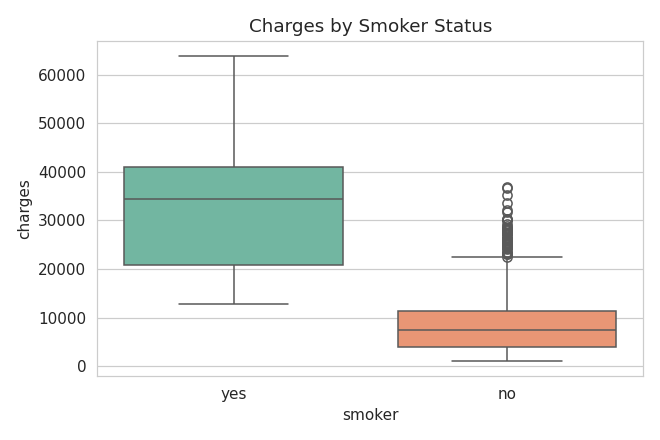

In [13]:
display(Image("plots/04_smoker_vs_charges.png"))

**Observation:** Smokers have dramatically higher median charges than non-smokers, with almost no overlap between the two boxes. `smoker` is visibly the single strongest predictor in the dataset.

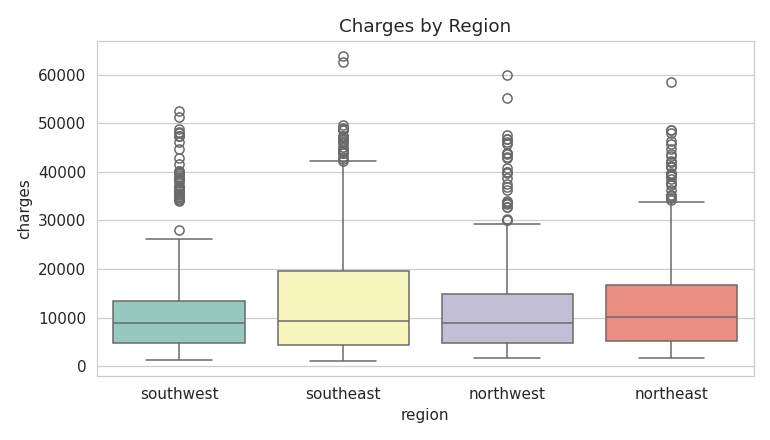

In [14]:
display(Image("plots/05_region_vs_charges.png"))

**Observation:** Median charges are broadly similar across all four regions, with the southeast slightly higher. Region does not look like a strong predictor compared to smoking status.

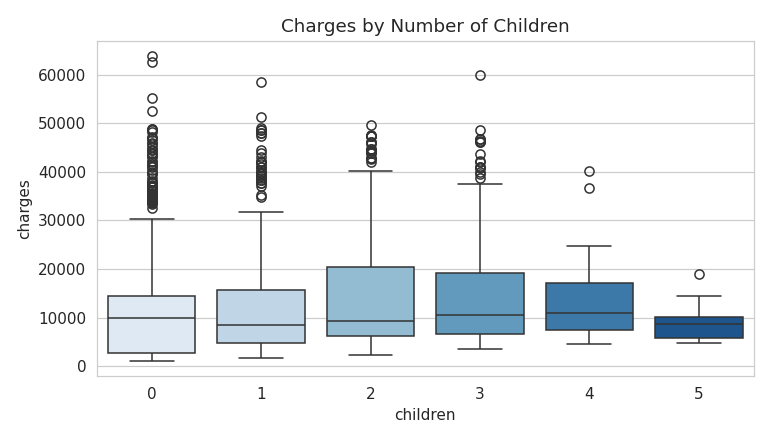

In [15]:
display(Image("plots/06_children_vs_charges.png"))

**Observation:** There's no strong or clearly increasing trend between number of children and charges — medians stay roughly in the same range across 0–5 children.

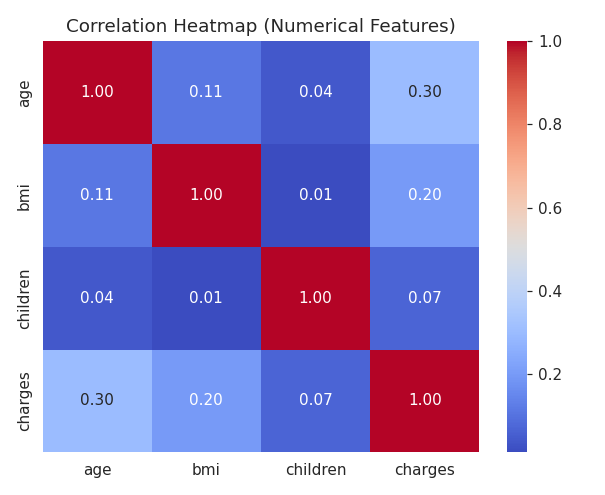

In [16]:
display(Image("plots/07_correlation_heatmap.png"))

**Observation:** Among numeric features, `age` has the strongest linear correlation with `charges` (~0.30), followed by `bmi` (~0.20); `children` is nearly uncorrelated (~0.07). Note this heatmap only captures numeric columns — it doesn't reflect `smoker`, which the boxplot above shows is actually the dominant factor. **Correlation here describes association, not causation.**

## Phase 4 — Define Features and Target
- **X (features):** `age`, `sex`, `bmi`, `children`, `smoker`, `region`
- **y (target):** `charges`

`charges` is the target because it's the continuous outcome we want to predict for new customers — everything else describes a customer, and `charges` is what an insurer actually needs to estimate.

In [17]:
X = df[["age", "sex", "bmi", "children", "smoker", "region"]]
y = df["charges"]
X.shape, y.shape

((1337, 6), (1337,))

## Phase 5 — Train/Test Split
We hold out 20% of the data as a test set. The model must be evaluated on data it never saw during training — otherwise we'd be measuring how well it memorized the training data, not how well it generalizes to new customers.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (1069, 6)  Test: (268, 6)


## Phase 6 — Preprocessing
Linear Regression needs numeric input, but `sex`, `smoker`, and `region` are categorical text. We apply **One-Hot Encoding** to convert each category into 0/1 columns.

We use a `ColumnTransformer` inside a `Pipeline` so preprocessing is **fitted only on the training data** (`fit` is called on `X_train`) and then just *applied* (`transform`) to the test set — this avoids data leakage, where information from the test set would otherwise leak into training.

In [19]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features),
])

## Phase 7 — Train Linear Regression (Baseline)
Linear Regression learns a weight (coefficient) for every feature, plus an intercept, such that:

`Predicted Charges = Intercept + (coef_1 × feature_1) + (coef_2 × feature_2) + ...`

It finds the coefficients that minimize the sum of squared errors between predicted and actual charges on the training data.

In [20]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])
baseline_pipeline.fit(X_train, y_train)
y_pred_base = baseline_pipeline.predict(X_test)

ohe = baseline_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
coefs = baseline_pipeline.named_steps["model"].coef_
intercept = baseline_pipeline.named_steps["model"].intercept_

print("Intercept:", round(intercept, 2))
for name, c in zip(feature_names, coefs):
    print(f"{name}: {c:.2f}")

Intercept: -11092.65
age: 248.21
bmi: 318.70
children: 533.01
sex_male: -101.54
smoker_yes: 23077.76
region_northwest: -391.76
region_southeast: -838.92
region_southwest: -659.14


**Interpretation:** `smoker_yes` has by far the largest coefficient (~+$23,000) — being a smoker adds roughly $23,000 to predicted charges, holding other features constant. `age`, `bmi`, and `children` all have positive coefficients (older, higher-BMI, and more-children customers cost more), while region coefficients are small compared to smoking status, matching what the EDA showed.

## Phase 8 — Model Evaluation
- **R²** — proportion of variance in charges explained by the model (0 to 1, higher is better).
- **Adjusted R²** — R² penalized for the number of predictors, useful for comparing models with different feature counts.
- **MAE** — average absolute error, in dollars.
- **MSE** — average squared error; large errors are penalized more heavily.
- **RMSE** — square root of MSE, back in dollar units, more sensitive to large errors than MAE.

In [21]:
def evaluate(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"R2": r2, "Adj_R2": adj_r2, "MAE": mae, "MSE": mse, "RMSE": rmse}

base_metrics = evaluate(y_test, y_pred_base, X_train.shape[1])
base_metrics

{'R2': 0.8069287081198013,
 'Adj_R2': 0.8024902876168083,
 'MAE': 4177.045561036321,
 'MSE': 35478020.675235584,
 'RMSE': np.float64(5956.342894363586)}

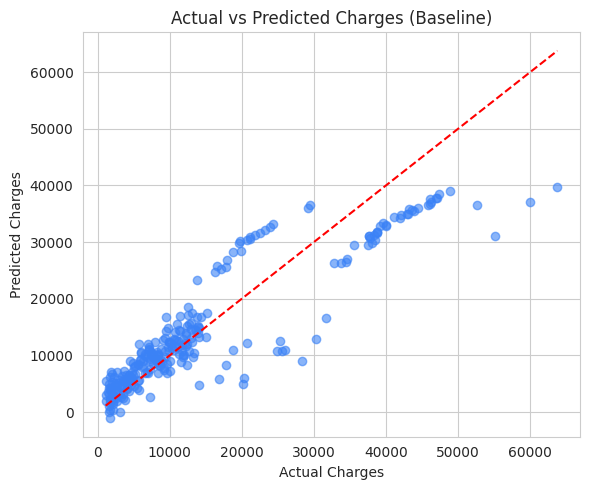

In [22]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_base, alpha=0.6, color="#3b82f6")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges (Baseline)")
plt.tight_layout()
plt.savefig("plots/08_actual_vs_predicted_baseline.png", dpi=110)
plt.show()

**Interpretation:** The baseline model explains about **80.7%** of the variance in charges (R² ≈ 0.807, Adjusted R² ≈ 0.802). On average, predictions are off by about **$4,177 (MAE)**, and RMSE (≈$5,956) being noticeably higher than MAE tells us there are some larger errors pulling it up — consistent with the actual-vs-predicted plot, where high-charge points (mostly smokers) scatter further from the red diagonal line.

## Phase 9 — Residual Analysis
Residual = Actual − Predicted. Ideally residuals scatter randomly around zero with no pattern; a pattern would mean the model is systematically missing something.

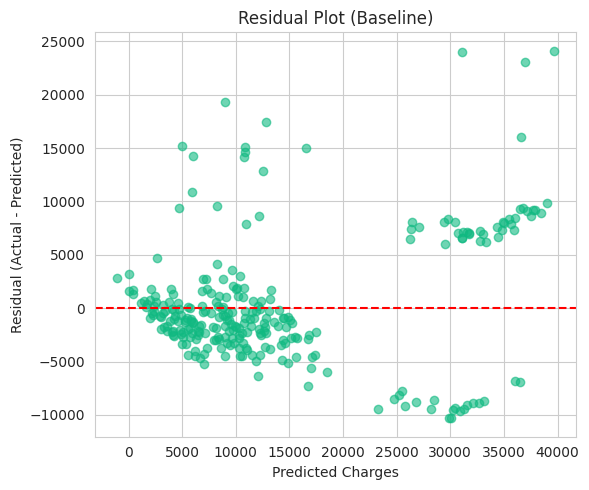

In [23]:
residuals = y_test - y_pred_base

plt.figure(figsize=(6, 5))
plt.scatter(y_pred_base, residuals, alpha=0.6, color="#10b981")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Baseline)")
plt.tight_layout()
plt.savefig("plots/09_residual_plot_baseline.png", dpi=110)
plt.show()

**Conclusion:** Residuals are not evenly scattered — there's a visible fan/curve shape, and a cluster of large positive residuals (model under-predicting) at higher predicted values. This is a sign of **heteroscedasticity** and suggests the model is missing an interaction effect, most likely between `smoker` and `bmi`/`age`, which the EDA scatter plots also hinted at. This motivates the improvement experiment below.

## Phase 10 — Model Improvement Experiment
Based on the EDA (BMI vs Charges plot) and residual pattern above, we test whether adding two **interaction features** — `age × smoker` and `bmi × smoker` — improves the model. These features let the model learn a steeper age/BMI effect specifically for smokers, instead of one shared slope for everyone.

In [24]:
df_fe = df.copy()
df_fe["age_smoker"] = df_fe["age"] * (df_fe["smoker"] == "yes").astype(int)
df_fe["bmi_smoker"] = df_fe["bmi"] * (df_fe["smoker"] == "yes").astype(int)

X_fe = df_fe[["age", "sex", "bmi", "children", "smoker", "region", "age_smoker", "bmi_smoker"]]
y_fe = df_fe["charges"]

X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe, y_fe, test_size=0.20, random_state=42
)

numeric_features_fe = ["age", "bmi", "children", "age_smoker", "bmi_smoker"]
preprocessor_fe = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features_fe),
    ("cat", OneHotEncoder(drop="first"), categorical_features),
])

fe_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("model", LinearRegression()),
])
fe_pipeline.fit(X_fe_train, y_fe_train)
y_pred_fe = fe_pipeline.predict(X_fe_test)
fe_metrics = evaluate(y_fe_test, y_pred_fe, X_fe_train.shape[1])
fe_metrics

{'R2': 0.8859571479859212,
 'Adj_R2': 0.8824345888503512,
 'MAE': 2831.6469777371767,
 'MSE': 20956065.618128683,
 'RMSE': np.float64(4577.779551062795)}

In [25]:
comparison = pd.DataFrame([base_metrics, fe_metrics], index=["Baseline", "Feature-Engineered"])
comparison

,R2,Adj_R2,MAE,MSE,RMSE
Baseline,0.806929,0.802490,4177.045561,3.547802e+07,5956.342894
Feature-Engineered,0.885957,0.882435,2831.646978,2.095607e+07,4577.779551


**Model selection:** The feature-engineered model improves **every** metric — R² rises from ~0.807 to ~0.886, Adjusted R² from ~0.802 to ~0.882, and RMSE drops from ~$5,956 to ~$4,578 (about 23% lower typical error). Since the improvement is consistent across R², Adjusted R², MAE, MSE, *and* RMSE together — not cherry-picked from a single metric — we select the **feature-engineered model as the final model**, not simply because it has the highest R² alone.

## Phase 11 — Save the Final Model
The final pipeline must accept the **raw 6 input columns** (not the engineered ones) so the Streamlit app can call it directly on user input. We wrap the interaction-feature step in a `FunctionTransformer` so it becomes part of the saved pipeline itself.

The interaction function lives in `pipeline_utils.py` (a plain importable module, not defined inline in the notebook) — this is required for `joblib`/`pickle` to be able to reload the pipeline later inside `app.py`.

In [26]:
import sys
sys.path.append("..")
from pipeline_utils import add_interaction_features

final_preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features_fe),
    ("cat", OneHotEncoder(drop="first"), categorical_features),
])

final_pipeline = Pipeline(steps=[
    ("add_features", FunctionTransformer(add_interaction_features)),
    ("preprocessor", final_preprocessor),
    ("model", LinearRegression()),
])
final_pipeline.fit(X_train, y_train)  # raw 6-column input

joblib.dump(final_pipeline, "../models/insurance_model.pkl")
joblib.dump(
    {"metrics": fe_metrics, "comparison": comparison.to_dict()},
    "../models/model_metadata.pkl",
)
print("Saved final pipeline and metadata to ../models/")

Saved final pipeline and metadata to ../models/


## Summary
| Step | Outcome |
|---|---|
| Cleaning | 1 duplicate removed, no missing values, no impossible values |
| Strongest predictor | `smoker` (EDA + coefficients) |
| Baseline R² / RMSE | 0.807 / $5,956 |
| Final (feature-engineered) R² / RMSE | 0.886 / $4,578 |
| Final model | Linear Regression + `age×smoker`, `bmi×smoker` interaction terms |
| Saved as | `models/insurance_model.pkl` (full pipeline, raw-input compatible) |

**Limitation & responsible-use note:** This model is trained on a small, U.S.-style sample dataset and should be treated as an educational estimate only — it must **not** be used for real insurance underwriting or medical decisions.